## 1. Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


## 2. Load Dataset

In [7]:
# Option A: Load from Kaggle
# import kagglehub
# path = kagglehub.dataset_download('yasserh/loan-default-dataset')
# df = pd.read_csv(f'{path}/Loan_Default.csv')

# Option B: Load from Google Drive (original setup)
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Loan_default/Loan_Default.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Exploratory Data Analysis

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [9]:
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values per column:
loan_limit                    3344
approv_in_adv                  908
loan_purpose                   134
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
property_value               15098
income                        9150
age                            200
submission_of_application      200
LTV                          15098
dtir1                        24121
dtype: int64


Target class distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

Class imbalance ratio: 3.06:1


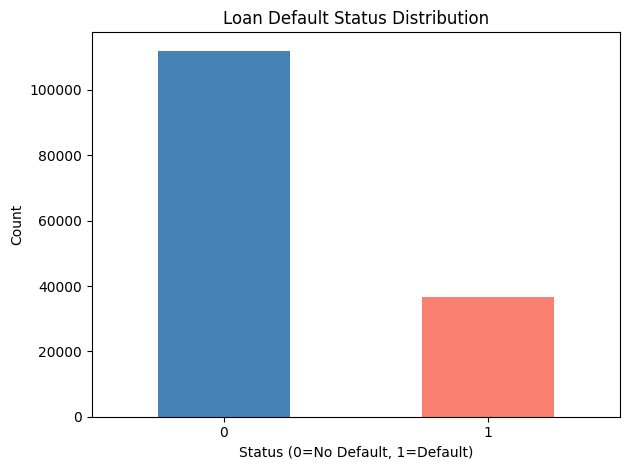

In [10]:
# Class distribution
print('Target class distribution:')
print(df['Status'].value_counts())
print(f"\nClass imbalance ratio: {df['Status'].value_counts()[0] / df['Status'].value_counts()[1]:.2f}:1")

df['Status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Loan Default Status Distribution')
plt.xlabel('Status (0=No Default, 1=Default)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Data Preprocessing

In [11]:
# Drop leaky, zero-variance, and ID columns
leaky_cols = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'ID', 'year']
df_clean = df.drop(columns=leaky_cols)

print(f'Original shape: {df.shape}')
print(f'Cleaned shape:  {df_clean.shape}')
print(f'Removed columns: {leaky_cols}')

Original shape: (148670, 34)
Cleaned shape:  (148670, 29)
Removed columns: ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'ID', 'year']


In [12]:
# FIX: Split BEFORE any imputation or encoding
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=38
)

print(f'Train size: {x_train.shape[0]:,} samples')
print(f'Test size:  {x_test.shape[0]:,} samples')

Train size: 118,936 samples
Test size:  29,734 samples


In [13]:
# FIX: Fit imputer ONLY on train, then transform both splits

# Numeric imputation
num_cols = x_train.select_dtypes(include=np.number).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
x_train[num_cols] = num_imputer.fit_transform(x_train[num_cols])
x_test[num_cols]  = num_imputer.transform(x_test[num_cols])

# Categorical imputation
cat_cols = x_train.select_dtypes(include='object').columns.tolist()
cat_imputer = SimpleImputer(strategy='most_frequent')
x_train[cat_cols] = cat_imputer.fit_transform(x_train[cat_cols])
x_test[cat_cols]  = cat_imputer.transform(x_test[cat_cols])

print('Imputation complete.')
print(f'Remaining NaNs in train: {x_train.isnull().sum().sum()}')
print(f'Remaining NaNs in test:  {x_test.isnull().sum().sum()}')

Imputation complete.
Remaining NaNs in train: 0
Remaining NaNs in test:  0


In [14]:
# FIX: Fit LabelEncoder on train categories only
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col].astype(str))
    # Handle unseen labels in test gracefully
    x_test[col] = x_test[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    le_dict[col] = le

print('Label encoding complete.')

Label encoding complete.


In [15]:
# FIX: Fit scaler ONLY on train, transform both
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print('Scaling complete.')

Scaling complete.


## 5. Model Training

In [16]:
# Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=38)
log_model.fit(x_train_scaled, y_train)
log_pred = log_model.predict(x_test_scaled)
print('Logistic Regression trained.')

Logistic Regression trained.


In [17]:
# Decision Tree — with max_depth to prevent overfitting on unseen patterns
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=38
)
dt_model.fit(x_train, y_train)
dt_pred = dt_model.predict(x_test)
print('Decision Tree trained.')

Decision Tree trained.


In [18]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    class_weight='balanced',
    random_state=38,
    n_jobs=-1
)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
print('Random Forest trained.')

Random Forest trained.


## 6. Model Evaluation

In [19]:
def evaluate_model(name, y_test, y_pred, y_prob=None):
    print(f'{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
    print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
    if y_prob is not None:
        print(f'ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}')
    else:
        print(f'ROC AUC:   {roc_auc_score(y_test, y_pred):.4f}')
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

  Logistic Regression
Accuracy:  0.6771
Precision: 0.4031
Recall:    0.6449
F1 Score:  0.4961
ROC AUC:   0.7252

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.69      0.76     22406
           1       0.40      0.64      0.50      7328

    accuracy                           0.68     29734
   macro avg       0.63      0.67      0.63     29734
weighted avg       0.74      0.68      0.70     29734



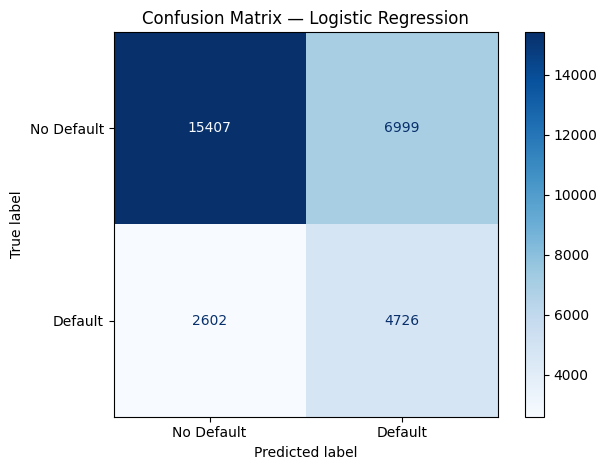

  Decision Tree
Accuracy:  0.8672
Precision: 0.7791
Recall:    0.6436
F1 Score:  0.7049
ROC AUC:   0.7919

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     22406
           1       0.78      0.64      0.70      7328

    accuracy                           0.87     29734
   macro avg       0.83      0.79      0.81     29734
weighted avg       0.86      0.87      0.86     29734



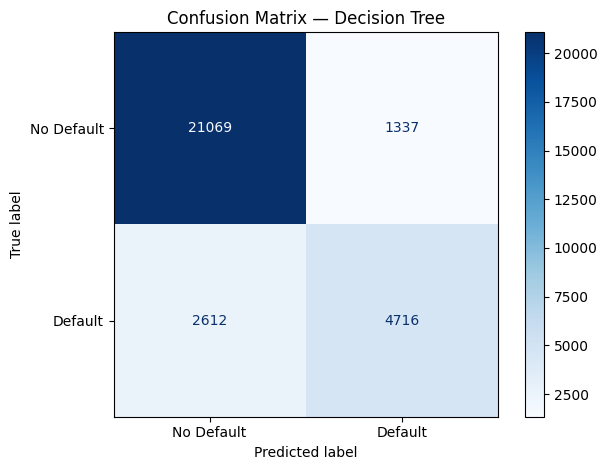

  Random Forest
Accuracy:  0.8799
Precision: 0.8109
Recall:    0.6687
F1 Score:  0.7329
ROC AUC:   0.8877

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     22406
           1       0.81      0.67      0.73      7328

    accuracy                           0.88     29734
   macro avg       0.85      0.81      0.83     29734
weighted avg       0.88      0.88      0.88     29734



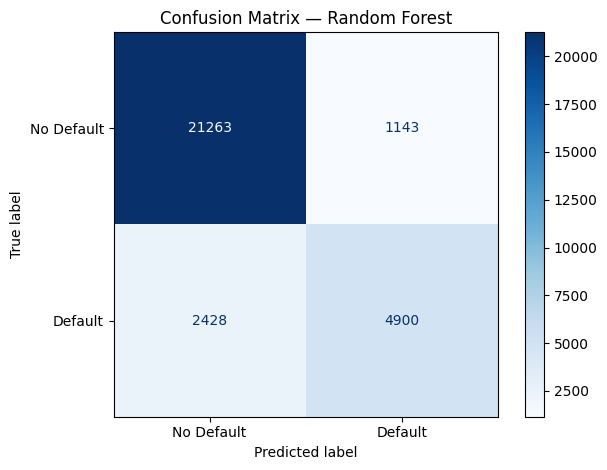

In [20]:
evaluate_model(
    'Logistic Regression',
    y_test, log_pred,
    y_prob=log_model.predict_proba(x_test_scaled)[:, 1]
)

evaluate_model(
    'Decision Tree',
    y_test, dt_pred
)

evaluate_model(
    'Random Forest',
    y_test, rf_pred,
    y_prob=rf_model.predict_proba(x_test)[:, 1]
)

## 7. Cross-Validation (More Reliable Evaluation)

In [21]:
# Stratified K-Fold cross-validation on full cleaned data (after encoding)
# Re-prepare full encoded dataset for CV
X_full = df_clean.drop('Status', axis=1).copy()
y_full = df_clean['Status']

# Impute and encode full dataset for CV
for col in X_full.select_dtypes(include=np.number).columns:
    X_full[col].fillna(X_full[col].median(), inplace=True)
for col in X_full.select_dtypes(include='object').columns:
    X_full[col].fillna(X_full[col].mode()[0], inplace=True)
    le_cv = LabelEncoder()
    X_full[col] = le_cv.fit_transform(X_full[col].astype(str))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=38)

print('5-Fold Cross-Validation Results (F1 Score):')
print('-' * 45)

models_cv = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=38),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_split=20, class_weight='balanced', random_state=38),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=20, class_weight='balanced', random_state=38, n_jobs=-1)
}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='f1', n_jobs=-1)
    print(f'{name:25s} — Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})')

5-Fold Cross-Validation Results (F1 Score):
---------------------------------------------
Logistic Regression       — Mean F1: 0.4566 (+/- 0.0151)
Decision Tree             — Mean F1: 0.7015 (+/- 0.0046)
Random Forest             — Mean F1: 0.7349 (+/- 0.0025)


## 8. Feature Importance

Top 15 Most Important Features (after removing leaky columns):
                  Feature  Importance
                      LTV    0.197659
           property_value    0.156132
                    dtir1    0.154931
              credit_type    0.130490
                   income    0.065302
         lump_sum_payment    0.038390
        Neg_ammortization    0.035825
 co-applicant_credit_type    0.033893
              loan_amount    0.032845
submission_of_application    0.024128
                loan_type    0.019138
             Credit_Score    0.018733
             loan_purpose    0.013508
   business_or_commercial    0.010682
                      age    0.010337


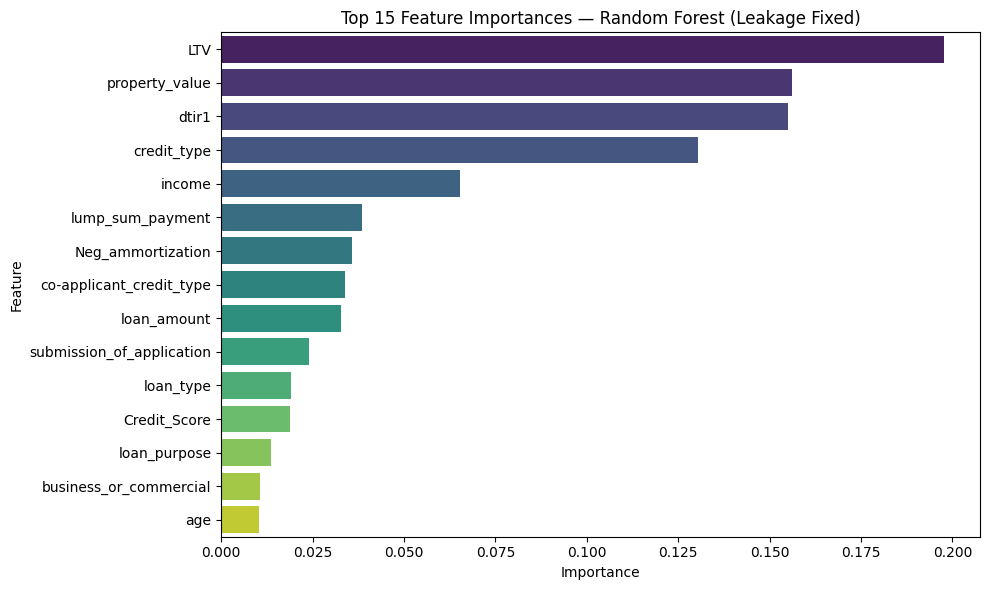

In [22]:
feature_importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('Top 15 Most Important Features (after removing leaky columns):')
print(feature_importances.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importances.head(15),
    x='Importance', y='Feature',
    palette='viridis'
)
plt.title('Top 15 Feature Importances — Random Forest (Leakage Fixed)')
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning (Best Model — Random Forest)

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=38, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1',        # ← use f1 instead of recall for balanced evaluation
    n_jobs=-1,
    verbose=1
)
grid.fit(x_train, y_train)
best_model = grid.best_estimator_

print(f'Best Parameters: {grid.best_params_}')
print(f'Best CV F1 Score: {grid.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': 20, 'min_samples_split': 20, 'n_estimators': 200}
Best CV F1 Score: 0.7359


  Tuned Random Forest (Final)
Accuracy:  0.8839
Precision: 0.8308
Recall:    0.6642
F1 Score:  0.7382
ROC AUC:   0.8899

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     22406
           1       0.83      0.66      0.74      7328

    accuracy                           0.88     29734
   macro avg       0.86      0.81      0.83     29734
weighted avg       0.88      0.88      0.88     29734



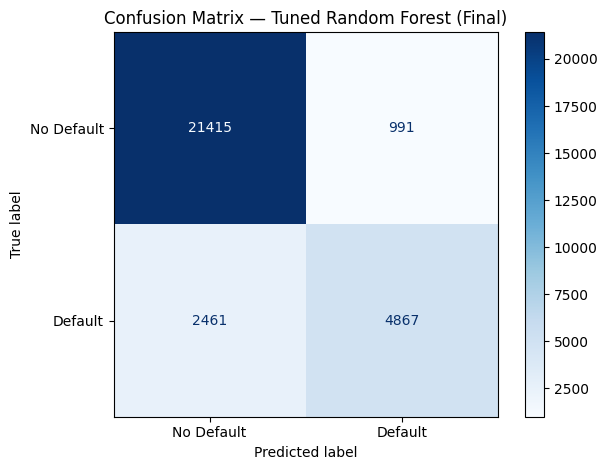

In [24]:
best_pred = best_model.predict(x_test)
evaluate_model(
    'Tuned Random Forest (Final)',
    y_test, best_pred,
    y_prob=best_model.predict_proba(x_test)[:, 1]
)

## 10. Save Model

In [25]:
joblib.dump(best_model, 'loan_default_model.pkl')
joblib.dump(scaler,     'loan_default_scaler.pkl')
joblib.dump(num_imputer,'loan_default_num_imputer.pkl')
joblib.dump(cat_imputer,'loan_default_cat_imputer.pkl')
print('Model and preprocessing artifacts saved.')

Model and preprocessing artifacts saved.
